## Name: D Vamsidhar 
## PRN: 24070149005
### Deep Convolutional GAN

In [5]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
import os

# Check for GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


In [25]:
# Hyperparameters
nz = 100       # Latent vector size (input to generator)
ndf = 64       # Feature maps in discriminator
ngf = 64       # Number of generator feature maps
nc = 3         # Number of output channels (CIFAR-10 has RGB images)
nc = 3         # Number of channels (3 for RGB images)
lr = 0.0002    # Learning rate
beta1 = 0.5    # Beta1 for Adam optimizer
batch_size = 128
epochs = 20

ngpu = 0 # Use 1 if GPU is used or 0 if CPU is used

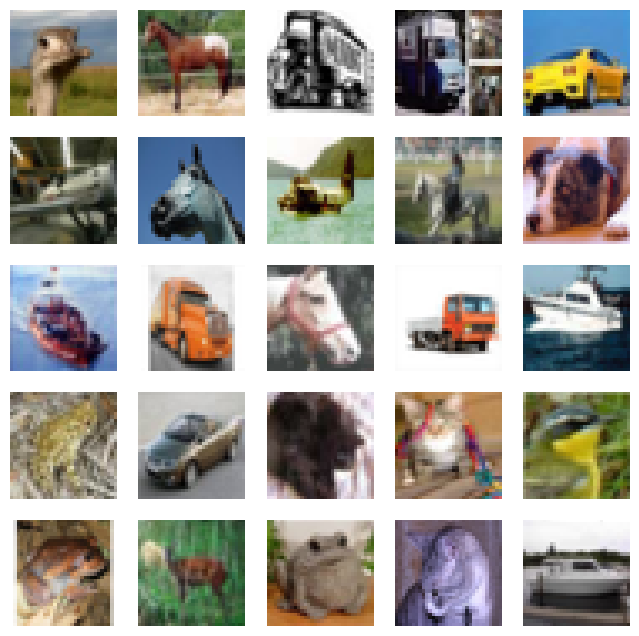

In [21]:
# Define transformations
transform = transforms.Compose([
    transforms.Resize(32),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))  # Adjusted for 3 channels
])

# Load CIFAR-10 dataset
dataset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
dataloader = torch.utils.data.DataLoader(dataset, batch_size=25, shuffle=True)  # Load 25 images

# Get a batch of images
dataiter = iter(dataloader)
images, labels = next(dataiter)

# Function to unnormalize and display images
def imshow(img):
    img = img / 2 + 0.5  # Unnormalize
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))  # Convert from Tensor image
    plt.axis('off')

# Plot 25 images in a grid
fig, axes = plt.subplots(5, 5, figsize=(8, 8))
for i, ax in enumerate(axes.flat):
    img = images[i]  # Get image
    img = img / 2 + 0.5  # Unnormalize
    npimg = img.numpy()
    ax.imshow(np.transpose(npimg, (1, 2, 0)))
    ax.axis('off')

plt.show()

In [14]:
# custom weights initialization called on ``netG`` and ``netD``
def weights_init(m):
    classname = m.__class__.__name__
    if classname.find('Conv') != -1:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif classname.find('BatchNorm') != -1:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)

In [15]:
class Generator(nn.Module):
    def __init__(self, nz, ngf, nc):
        super(Generator, self).__init__()
        self.main = nn.Sequential(
            # Input: Z (random noise) --> (ngf*8) x 4 x 4
            nn.ConvTranspose2d(nz, ngf * 8, 4, 1, 0, bias=False),
            nn.BatchNorm2d(ngf * 8),
            nn.ReLU(True),

            # (ngf*8) x 4 x 4 --> (ngf*4) x 8 x 8
            nn.ConvTranspose2d(ngf * 8, ngf * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf * 4),
            nn.ReLU(True),

            # (ngf*4) x 8 x 8 --> (ngf*2) x 16 x 16
            nn.ConvTranspose2d(ngf * 4, ngf * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf * 2),
            nn.ReLU(True),

            # (ngf*2) x 16 x 16 --> (ngf) x 32 x 32
            nn.ConvTranspose2d(ngf * 2, ngf, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf),
            nn.ReLU(True),

            # (ngf) x 32 x 32 --> (nc) x 32 x 32
            nn.ConvTranspose2d(ngf, nc, 4, 2, 1, bias=False),
            nn.Tanh()  # Output: 3-channel RGB image
        )

    def forward(self, input):
        return self.main(input)

In [17]:
# Create the generator
netG = Generator(ngpu, ngf, nc).to(device)

# Handle multi-GPU if desired
if (device.type == 'cuda') and (ngpu > 1):
    netG = nn.DataParallel(netG, list(range(ngpu)))

# Apply the ``weights_init`` function to randomly initialize all weights
#  to ``mean=0``, ``stdev=0.02``.
netG.apply(weights_init)

# Print the model
print(netG)

Generator(
  (main): Sequential(
    (0): ConvTranspose2d(0, 512, kernel_size=(4, 4), stride=(1, 1), bias=False)
    (1): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): ConvTranspose2d(512, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (4): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): ConvTranspose2d(256, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (7): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): ReLU(inplace=True)
    (9): ConvTranspose2d(128, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (10): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (11): ReLU(inplace=True)
    (12): ConvTranspose2d(64, 3, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (13): Tanh()
  )
)


In [8]:
class Discriminator(nn.Module):
    def __init__(self, nc, ndf):
        super(Discriminator, self).__init__()
        self.main = nn.Sequential(
            # Input: (nc) x 32 x 32 --> (ndf) x 16 x 16
            nn.Conv2d(nc, ndf, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),

            # (ndf) x 16 x 16 --> (ndf*2) x 8 x 8
            nn.Conv2d(ndf, ndf * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf * 2),
            nn.LeakyReLU(0.2, inplace=True),

            # (ndf*2) x 8 x 8 --> (ndf*4) x 4 x 4
            nn.Conv2d(ndf * 2, ndf * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf * 4),
            nn.LeakyReLU(0.2, inplace=True),

            # (ndf*4) x 4 x 4 --> (ndf*8) x 1 x 1
            nn.Conv2d(ndf * 4, ndf * 8, 4, 1, 0, bias=False),
            nn.BatchNorm2d(ndf * 8),
            nn.LeakyReLU(0.2, inplace=True),

            # Output: Single scalar (0: fake, 1: real)
            nn.Conv2d(ndf * 8, 1, 1, 1, 0, bias=False),
            nn.Sigmoid()
        )

    def forward(self, input):
        return self.main(input).view(-1)

In [20]:
# Create the discriminator
netD = Discriminator(ngpu, ndf).to(device)

# Handle multi-GPU if desired
if (device.type == 'cuda') and (ngpu > 1):
    netD = nn.DataParallel(netD, list(range(ngpu)))

# Apply the ``weights_init`` function to randomly initialize all weights
#  to ``mean=0``, ``stdev=0.02``.
netD.apply(weights_init)

# Print the model
print(netD)

Discriminator(
  (main): Sequential(
    (0): Conv2d(0, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (1): LeakyReLU(negative_slope=0.2, inplace=True)
    (2): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (4): LeakyReLU(negative_slope=0.2, inplace=True)
    (5): Conv2d(128, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (6): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): LeakyReLU(negative_slope=0.2, inplace=True)
    (8): Conv2d(256, 512, kernel_size=(4, 4), stride=(1, 1), bias=False)
    (9): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): LeakyReLU(negative_slope=0.2, inplace=True)
    (11): Conv2d(512, 1, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (12): Sigmoid()
  )
)


In [10]:
transform = transforms.Compose([
    transforms.Resize(32),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

dataset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
dataloader = torch.utils.data.DataLoader(dataset, batch_size=batch_size, shuffle=True)

100%|██████████| 170M/170M [01:44<00:00, 1.63MB/s] 


In [22]:
netG = Generator(nz, ngf, nc).to(device)
netD = Discriminator(nc, ndf).to(device)

criterion = nn.BCELoss()
optimizerG = optim.Adam(netG.parameters(), lr=lr, betas=(beta1, 0.999))
optimizerD = optim.Adam(netD.parameters(), lr=lr, betas=(beta1, 0.999))

In [26]:
real_label = 1.0
fake_label = 0.0

fixed_noise = torch.randn(64, nz, 1, 1, device=device)  # Fixed noise for tracking progress

for epoch in range(epochs):
    for i, (real_images, _) in enumerate(dataloader):
        real_images = real_images.to(device)
        b_size = real_images.size(0)

        # Train Discriminator
        optimizerD.zero_grad()
        output = netD(real_images).view(-1)
        lossD_real = criterion(output, torch.full_like(output, real_label, device=device))  # Match shape
        lossD_real.backward()

        noise = torch.randn(b_size, nz, 1, 1, device=device)
        fake_images = netG(noise)
        output = netD(fake_images.detach()).view(-1)
        lossD_fake = criterion(output, torch.full_like(output, fake_label, device=device))  # Match shape
        lossD_fake.backward()

        optimizerD.step()

        # Train Generator
        optimizerG.zero_grad()
        output = netD(fake_images).view(-1)
        lossG = criterion(output, torch.full_like(output, real_label, device=device))  # Match shape
        lossG.backward()
        optimizerG.step()

        if i % 100 == 0:
            print(f"Epoch [{epoch+1}/{epochs}] | Step [{i}/{len(dataloader)}] | Loss D: {lossD_real+lossD_fake:.4f} | Loss G: {lossG:.4f}")

    # Save Progress Images
    with torch.no_grad():
        fake_images = netG(fixed_noise).cpu()
    torchvision.utils.save_image(fake_images, f"generated_epoch_{epoch+1}.png", normalize=True)

Epoch [1/20] | Step [0/2000] | Loss D: 1.1035 | Loss G: 0.9554
Epoch [1/20] | Step [100/2000] | Loss D: 0.9332 | Loss G: 1.1162
Epoch [1/20] | Step [200/2000] | Loss D: 0.8409 | Loss G: 1.2097
Epoch [1/20] | Step [300/2000] | Loss D: 0.6581 | Loss G: 1.4386
Epoch [1/20] | Step [400/2000] | Loss D: 0.7171 | Loss G: 1.3399
Epoch [1/20] | Step [500/2000] | Loss D: 0.8136 | Loss G: 1.4771
Epoch [1/20] | Step [600/2000] | Loss D: 0.4878 | Loss G: 1.7369
Epoch [1/20] | Step [700/2000] | Loss D: 1.3150 | Loss G: 1.7339
Epoch [1/20] | Step [800/2000] | Loss D: 0.2729 | Loss G: 2.0585
Epoch [1/20] | Step [900/2000] | Loss D: 0.5400 | Loss G: 2.3108
Epoch [1/20] | Step [1000/2000] | Loss D: 0.3602 | Loss G: 2.3989
Epoch [1/20] | Step [1100/2000] | Loss D: 0.2994 | Loss G: 2.3923
Epoch [1/20] | Step [1200/2000] | Loss D: 0.1759 | Loss G: 2.5833
Epoch [1/20] | Step [1300/2000] | Loss D: 0.1780 | Loss G: 2.8476
Epoch [1/20] | Step [1400/2000] | Loss D: 0.1139 | Loss G: 2.7893
Epoch [1/20] | Step [1

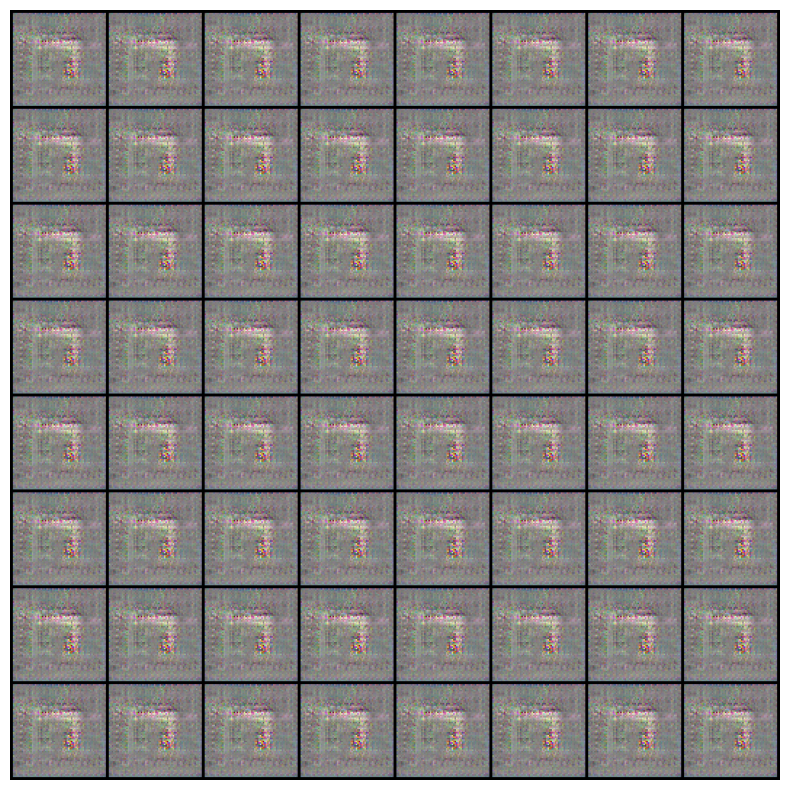

In [27]:
def show_generated_images():
    with torch.no_grad():
        fake_images = netG(fixed_noise).cpu()
    plt.figure(figsize=(10, 10))
    plt.axis("off")
    plt.imshow(np.transpose(torchvision.utils.make_grid(fake_images[:64], padding=2, normalize=True), (1, 2, 0)))
    plt.show()

show_generated_images()